In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

import torch

from src.decoder import VAE_Decoder
from src.encoder import VAE_Encoder

from utils.utils import sample_from_vae, interpolate_between_images, interpolate_to_gif
from utils.dataset import EmojiDataset
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
encoder = VAE_Encoder().to(device)
decoder = VAE_Decoder().to(device)

checkpoint = torch.load(project_root / 'checkpoints/vae/vae_epoch_0035.pth', map_location=device)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

encoder.eval();
decoder.eval();

/tmp/ipykernel_136129/113708653.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(project_root / 'checkpoints/vae/vae_epoch_0035.pth', map_location

In [4]:
tokenizer = None
dataset = EmojiDataset(project_root / 'data/emoji_dataset_128x128/emoji_dataset.json', image_size=128, tokenize=False)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

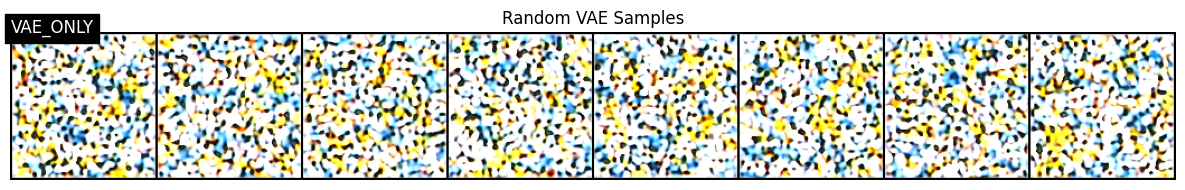

In [5]:
sample_from_vae(decoder, device)

In [6]:
IMG1_ID = 1
IMG2_ID = 627

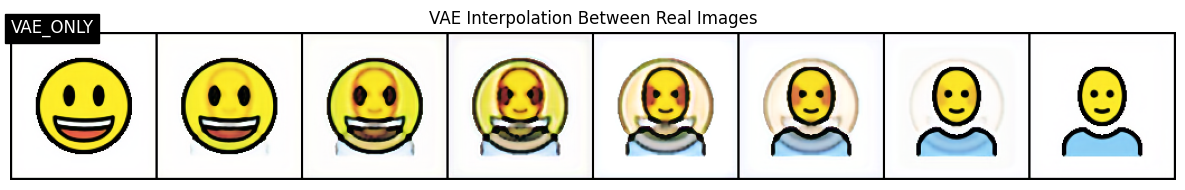

In [7]:
interpolate_between_images(encoder, decoder, dataset, IMG1_ID, IMG2_ID, device)

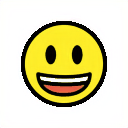

In [8]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID, device, steps=32)

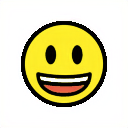

In [10]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID - 300, device, steps=32)

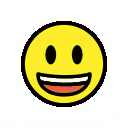

In [12]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID - 530, device, steps=32)